### E-Commerce Business Analysis

In [28]:
# Library
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt
import numpy as np
import scipy.stats
from sklearn.metrics import mean_squared_error
from math import sqrt
import os
from os import listdir
from datetime import datetime
import pandas as pd
from matplotlib.dates import DateFormatter
import matplotlib.ticker as ticker
import matplotlib.dates as mdates
from sklearn.linear_model import LinearRegression
import seaborn as sn
import plotly.express as px
import kagglehub
import seaborn as sns
print("listo")

listo


In [ ]:
#Extrar desde kaggle: https://www.kaggle.com/datasets/umuttuygurr/e-commerce-customer-behavior-and-sales-analysis-tr
import kagglehub

# Download latest version
path = kagglehub.dataset_download("umuttuygurr/e-commerce-customer-behavior-and-sales-analysis-tr")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Josefina Urquiza\.cache\kagglehub\datasets\umuttuygurr\e-commerce-customer-behavior-and-sales-analysis-tr\versions\2


In [9]:
# El link se saca de lo que me dice kaggle antes
df = pd.read_csv("C:/Users/Josefina Urquiza/.cache/kagglehub/datasets/umuttuygurr/e-commerce-customer-behavior-and-sales-analysis-tr/versions/2/ecommerce_customer_behavior_dataset_v2.csv")

df

,Order_ID,Customer_ID,Date,Age,Gender,City,Product_Category,Unit_Price,Quantity,Discount_Amount,Total_Amount,Payment_Method,Device_Type,Session_Duration_Minutes,Pages_Viewed,Is_Returning_Customer,Delivery_Time_Days,Customer_Rating
0,ORD_000001-1,CUST_00001,2023-05-29,40,Male,Ankara,Books,29.18,1,0.00,29.18,Digital Wallet,Mobile,14,9,True,13,4
1,ORD_000001-2,CUST_00001,2023-10-12,40,Male,Ankara,Home & Garden,644.40,1,138.05,506.35,Credit Card,Desktop,14,8,True,6,2
2,ORD_000001-3,CUST_00001,2023-12-05,40,Male,Ankara,Sports,332.82,5,0.00,1664.10,Credit Card,Mobile,15,10,True,9,4
3,ORD_000002-1,CUST_00002,2023-05-11,33,Male,Istanbul,Food,69.30,5,71.05,275.45,Digital Wallet,Desktop,16,13,True,4,4
4,ORD_000002-2,CUST_00002,2023-06-16,33,Male,Istanbul,Beauty,178.15,3,0.00,534.45,Credit Card,Mobile,14,7,True,6,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17044,ORD_004999-1,CUST_04999,2024-01-16,44,Male,Antalya,Beauty,68.65,2,0.00,137.30,Digital Wallet,Mobile,14,10,False,6,1
17045,ORD_005000-1,CUST_05000,2023-02-22,24,Female,Eskisehir,Beauty,156.12,1,0.00,156.12,Credit Card,Mobile,15,8,True,7,5
17046,ORD_005000-2,CUST_05000,2023-06-29,24,Female,Eskisehir,Home & Garden,1065.24,3,0.00,3195.72,Credit Card,Desktop,17,11,True,5,4
17047,ORD_005000-3,CUST_05000,2023-12-29,24,Female,Eskisehir,Books,47.73,2,8.80,86.66,Credit Card,Desktop,13,11,True,12,2


In [10]:
# Configuracion SQL
%load_ext sql

print("Configuracion y librerias OK")

The sql extension is already loaded. To reload it, use:
  %reload_ext sql
Configuracion y librerias OK


In [11]:
# Usar un archivo como SQLite como base de datos
database_filename = 'ecommerce_customer_behavior.db'
df.to_sql('ecommerce_customer_behavior', f'sqlite:///{database_filename}', if_exists='replace', index=False)

# Conexion a la base de datos generada
%sql sqlite:///ecommerce_customer_behavior.db

#Configuracion de sql (revisar)
%config SqlMagic.style = '_DEPRECATED_DEFAULT'

In [12]:
# Primera consulta, mostrar la data y ver si funciona el sql
%sql SELECT * FROM ecommerce_customer_behavior LIMIT 10;

 * sqlite:///ecommerce_customer_behavior.db
   sqlite:///ecommerce_sales_data.db
Done.


Order_ID,Customer_ID,Date,Age,Gender,City,Product_Category,Unit_Price,Quantity,Discount_Amount,Total_Amount,Payment_Method,Device_Type,Session_Duration_Minutes,Pages_Viewed,Is_Returning_Customer,Delivery_Time_Days,Customer_Rating
ORD_000001-1,CUST_00001,2023-05-29,40,Male,Ankara,Books,29.18,1,0.0,29.18,Digital Wallet,Mobile,14,9,1,13,4
ORD_000001-2,CUST_00001,2023-10-12,40,Male,Ankara,Home & Garden,644.4,1,138.05,506.35,Credit Card,Desktop,14,8,1,6,2
ORD_000001-3,CUST_00001,2023-12-05,40,Male,Ankara,Sports,332.82,5,0.0,1664.1,Credit Card,Mobile,15,10,1,9,4
ORD_000002-1,CUST_00002,2023-05-11,33,Male,Istanbul,Food,69.3,5,71.05,275.45,Digital Wallet,Desktop,16,13,1,4,4
ORD_000002-2,CUST_00002,2023-06-16,33,Male,Istanbul,Beauty,178.15,3,0.0,534.45,Credit Card,Mobile,14,7,1,6,4
ORD_000003-1,CUST_00003,2023-02-27,42,Male,Konya,Toys,198.28,2,0.0,396.56,Credit Card,Tablet,10,9,0,6,2
ORD_000003-2,CUST_00003,2024-01-03,42,Male,Konya,Home & Garden,526.85,5,0.0,2634.25,Digital Wallet,Desktop,11,8,1,6,5
ORD_000004-1,CUST_00004,2024-02-13,53,Male,Izmir,Fashion,96.2,5,97.78,383.22,Credit Card,Desktop,16,15,0,4,5
ORD_000005-1,CUST_00005,2023-03-16,32,Male,Ankara,Home & Garden,533.67,3,0.0,1601.01,Bank Transfer,Mobile,12,8,0,5,5
ORD_000005-2,CUST_00005,2023-06-12,32,Male,Ankara,Toys,73.06,4,0.0,292.24,Credit Card,Mobile,13,12,1,7,2


####  01. Definir el problema: 

Identificar los factores que influyen en la recompra y el revenue para aumentar la rentabilidad

02. Entendimiento del negocio

Primero es necesario entender bien el dataset.

In [ ]:
# Algunas metricas estadisticas basicas y de exploracion general del dataset()
print(df.info())
#No hay nulos ni duplicados
# df.isnull().sum()
# df.duplicated().sum()

<class 'pandas.DataFrame'>
RangeIndex: 17049 entries, 0 to 17048
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Order_ID                  17049 non-null  str    
 1   Customer_ID               17049 non-null  str    
 2   Date                      17049 non-null  str    
 3   Age                       17049 non-null  int64  
 4   Gender                    17049 non-null  str    
 5   City                      17049 non-null  str    
 6   Product_Category          17049 non-null  str    
 7   Unit_Price                17049 non-null  float64
 8   Quantity                  17049 non-null  int64  
 9   Discount_Amount           17049 non-null  float64
 10  Total_Amount              17049 non-null  float64
 11  Payment_Method            17049 non-null  str    
 12  Device_Type               17049 non-null  str    
 13  Session_Duration_Minutes  17049 non-null  int64  
 14  Pages_Viewed     

In [17]:
print(df.describe())


                Age    Unit_Price      Quantity  Discount_Amount  \
count  17049.000000  17049.000000  17049.000000     17049.000000   
mean      34.945745    447.901689      3.011379        69.788135   
std       11.046855    722.319705      1.417027       240.704662   
min       18.000000      5.050000      1.000000         0.000000   
25%       26.000000     73.260000      2.000000         0.000000   
50%       35.000000    174.680000      3.000000         0.000000   
75%       42.000000    494.570000      4.000000        32.710000   
max       75.000000   7900.010000      5.000000      6538.290000   

       Total_Amount  Session_Duration_Minutes  Pages_Viewed  \
count  17049.000000              17049.000000  17049.000000   
mean    1277.438711                 14.535633      9.003109   
std     2358.436375                  2.925524      2.259954   
min        6.210000                  4.000000      1.000000   
25%      172.970000                 13.000000      7.000000   
50%      

In [ ]:
#Configurar la fecha
df["Date"] = pd.to_datetime(df["Date"])
df

,Order_ID,Customer_ID,Date,Age,Gender,City,Product_Category,Unit_Price,Quantity,Discount_Amount,Total_Amount,Payment_Method,Device_Type,Session_Duration_Minutes,Pages_Viewed,Is_Returning_Customer,Delivery_Time_Days,Customer_Rating
0,ORD_000001-1,CUST_00001,2023-05-29,40,Male,Ankara,Books,29.18,1,0.00,29.18,Digital Wallet,Mobile,14,9,True,13,4
1,ORD_000001-2,CUST_00001,2023-10-12,40,Male,Ankara,Home & Garden,644.40,1,138.05,506.35,Credit Card,Desktop,14,8,True,6,2
2,ORD_000001-3,CUST_00001,2023-12-05,40,Male,Ankara,Sports,332.82,5,0.00,1664.10,Credit Card,Mobile,15,10,True,9,4
3,ORD_000002-1,CUST_00002,2023-05-11,33,Male,Istanbul,Food,69.30,5,71.05,275.45,Digital Wallet,Desktop,16,13,True,4,4
4,ORD_000002-2,CUST_00002,2023-06-16,33,Male,Istanbul,Beauty,178.15,3,0.00,534.45,Credit Card,Mobile,14,7,True,6,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17044,ORD_004999-1,CUST_04999,2024-01-16,44,Male,Antalya,Beauty,68.65,2,0.00,137.30,Digital Wallet,Mobile,14,10,False,6,1
17045,ORD_005000-1,CUST_05000,2023-02-22,24,Female,Eskisehir,Beauty,156.12,1,0.00,156.12,Credit Card,Mobile,15,8,True,7,5
17046,ORD_005000-2,CUST_05000,2023-06-29,24,Female,Eskisehir,Home & Garden,1065.24,3,0.00,3195.72,Credit Card,Desktop,17,11,True,5,4
17047,ORD_005000-3,CUST_05000,2023-12-29,24,Female,Eskisehir,Books,47.73,2,8.80,86.66,Credit Card,Desktop,13,11,True,12,2


In [ ]:
##### Algunas pregundas: 
# - ¿Hay valores negativos?
# - ¿Discount_Amount > Unit_Price * Quantity?
# - ¿Total_Amount está bien calculado?
#Corroboramos que esta bien porque da practicamente 0: El Total_Amount está perfectamente calculado.
df["calculated_total"] = df["Unit_Price"] * df["Quantity"] - df["Discount_Amount"]
(df["calculated_total"] - df["Total_Amount"]).abs().sum()

np.float64(8.042224663995512e-10)

Algunas consideraciones:
- Edad: vemos un público bastante joven-adulto. Lo que podría implicar, uso alto del celular y un buen potencial de recompra digital.
- Unit_Price: La dispersion es alta y fuerte asimetría positiva. Hay productos muy caros que elevan la media. Esto puede deberse que el revenue puede estar concentrado en pocos productos. Es necesirio analizar distribución por categoría.
- Discount_Amount: El 50% de las compras NO tiene descuento. Pero en el resto los descuentos son altos hay descuentos enormes.
- Total_Amount: alta asimetría, lo que refuerza que hay compras muy grandes que cambian la media.
- Session Duration: Media: 14.5 minutos con un rango entre 4 y 26 min. Muy consistente. No parece haber valores raros.
- Pages Viewed: Media: 9 con un rango entre 1 y 18. Esto puede ser importante para la conversion o la recompra.
- Delivery Time: hay una media de 6.5 días y con un maximo de 25 dias, que es alto. Puede ser importante para la recompra
- Customer Rating: representa la calificación que el cliente le dio a su compra (1-5). Media: 3.9 / 5  Bastante bueno.

#### 03. Análisis Exploratorio Orientado al Negocio
3.1 Entender la recompra (Variable Target #1)

In [ ]:
#Pregunta Qué porcentaje recompra?
df["Is_Returning_Customer"].value_counts(normalize=True)
#El 88% de los clientes vuelve a comprar, lo cual es extremadamente alto para un e-commerce.

Is_Returning_Customer
True     0.882105
False    0.117895
Name: proportion, dtype: float64

In [ ]:
#Verifiquemos la variable Is_Returning_Customer, porque puede significar dos cosas:

# - Cliente que ya había comprado antes en la plataforma
# - Cliente que volvió después de esta compra
# no es lo mismo
# Verificar: 
# Cuantos clientes unicos hay?
df["Customer_ID"].nunique() # 5000 clientes unicos

#Cuántas órdenes promedio por cliente?
df.groupby("Customer_ID")["Order_ID"].count().mean() # en promedio cada cliente compra 3.4 veces, entonces:

np.float64(3.4098)

In [ ]:
# ver la distribución de compras por cliente.
orders_per_customer = df.groupby("Customer_ID")["Order_ID"].count()

orders_per_customer.describe()
(orders_per_customer == 1).mean()

# 17.84% de los clientes compraron solo 1 vez.

np.float64(0.1784)

In [ ]:
#Recompra vs Delivery Time
df.groupby("Is_Returning_Customer")["Delivery_Time_Days"].mean()


# Si clientes que esperan más días vuelven menos → insight fuerte
# Clientes que NO vuelven → 6.41 días
# Clientes que sí vuelven → 6.51 días
#  Diferencia: 0.1 días, eso es prácticamente nada.

Is_Returning_Customer
False    6.415423
True     6.515393
Name: Delivery_Time_Days, dtype: float64

In [ ]:
# Recompra vs puntaje
df.groupby("Is_Returning_Customer")["Customer_Rating"].mean()

# La diferencia entre si se retornan o no es de 0.024 puntos, eso es prácticamente nada.
# Esto nos dice que el Customer Rating no está explicando la recompra

Is_Returning_Customer
False    3.877612
True     3.902321
Name: Customer_Rating, dtype: float64

In [ ]:
# Discount vs Recompra
df.groupby("Is_Returning_Customer")["Discount_Amount"].mean()

# La diferencia es de 0.56, por lo que es irrelevante. 
# El descuento no está explicando la recompra.

Is_Returning_Customer
False    70.286368
True     69.721545
Name: Discount_Amount, dtype: float64

Hasta ahora descartamos como factores fuertes de recompra:

- Delivery Time
- Customer Rating
- Discount

### 3.2. Análisis de Revenue
Ahora miramos revenue como empresa.

Product_Category
Electronics      10481897.65
Home & Garden     4023903.94
Sports            3205086.99
Fashion           1577035.70
Toys              1014237.53
Beauty             694437.02
Food               422054.65
Books              360399.11
Name: Total_Amount, dtype: float64


<Axes: ylabel='Product_Category'>

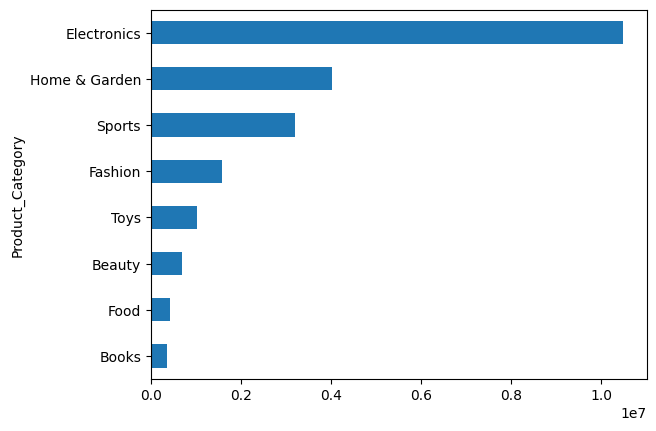

In [ ]:
# Revenue total por categoría:
print(df.groupby("Product_Category")["Total_Amount"].sum().sort_values(ascending=False))

#plot
df.groupby("Product_Category")["Total_Amount"].sum().sort_values().plot(kind="barh")



Vemos que la categoria Electronics domina completamente el revenue.
No es que lidera sino que duplica a la segunda categoría, es mucho.

Con esto vemos que el revenue NO está distribuido de forma uniforme.

Eso abre varias preguntas estratégicas:

- ¿Electronics tiene precios más altos o más cantidad vendida?
- ¿Electronics tiene más recompra?
- ¿Los clientes que compran Electronics gastan más en general?
- ¿El margen será mayor o menor en esa categoría?


Puede ser que no alcance con ver el revenue total. Eso puede estar inflado porque:
- Tiene productos caros
- Tiene muchos pedidos
- Tiene ambas cosas

In [ ]:
#Precio promedio por categoria
df.groupby("Product_Category")["Unit_Price"].mean().sort_values(ascending=False)


# Se ve que el revenue de Electronics es porque los precios son altos.
#Por ejemplo: 
# - precio promedio es: 2.5x mayor que Home & Garden; 3.5x mayor que Sports; 32x mayor que Books


Product_Category
Electronics      1766.716461
Home & Garden     690.938840
Sports            492.898719
Fashion           276.358716
Toys              168.968837
Beauty            112.009322
Food               70.591032
Books              55.838472
Name: Unit_Price, dtype: float64

In [ ]:
#Cantidad promedio por categoría
df.groupby("Product_Category")["Quantity"].mean().sort_values(ascending=False)


# Todas están alrededor de 3 unidades. No hay diferencia entre las categorias
#  Electronics vende casi la misma cantidad que Books o Food.


Product_Category
Sports           3.049822
Books            3.049411
Food             3.034237
Electronics      3.026519
Toys             3.015789
Home & Garden    2.987864
Beauty           2.967450
Fashion          2.956226
Name: Quantity, dtype: float64

Entonces el revenue de Electronics NO se explica por volumen. Sino que se explica por el precio unitario extremadamente alto.
Eso significa que el negocio está estructurado así:

Mismo comportamiento de compra
Mismo nivel de unidades
Pero distinto ticket promedio

In [ ]:
# B. Revenue por ciudad
df.groupby("City")["Total_Amount"].sum().sort_values(ascending=False)

# Parece que Estanbul es el mercado mas importante.
# Esto puede deberse a:
# - Más clientes
# - Más órdenes
# - Ticket promedio más alto
# - Más productos premium vendidos

# Todavía no sabemos cuál.



City
Istanbul     5646595.78
Ankara       3052443.10
Izmir        2651743.92
Bursa        2317028.10
Antalya      1661594.15
Gaziantep    1573422.25
Adana        1512320.19
Konya        1363152.80
Kayseri      1091658.53
Eskisehir     909093.77
Name: Total_Amount, dtype: float64

In [ ]:
# Clientes por ciudad
df.groupby("City")["Customer_ID"].nunique().sort_values(ascending=False)

City
Istanbul     1284
Ankara        735
Izmir         600
Bursa         496
Adana         378
Antalya       374
Gaziantep     349
Konya         317
Kayseri       257
Eskisehir     210
Name: Customer_ID, dtype: int64

count     5000.000000
mean      4355.810518
std       5274.546636
min         14.280000
25%        889.410000
50%       2493.925000
75%       5796.297500
max      50628.150000
Name: Total_Amount, dtype: float64


<Axes: xlabel='Total_Amount', ylabel='Count'>

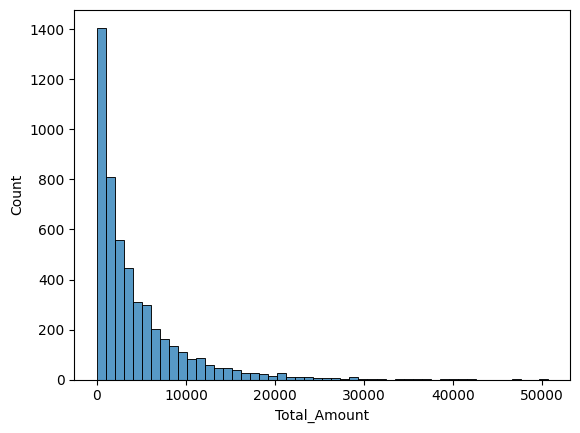

In [ ]:

customer_revenue = df.groupby("Customer_ID")["Total_Amount"].sum()
print(customer_revenue.describe())

sns.histplot(customer_revenue, bins=50)

# Existe una cola larga derecha, por lo que revenue concentrado en pocos clientes.
# La media es bastante mayor que la mediana. Por eje. 20% de clientes generan 60-70% del revenue.
# Por lo que hay Hay clientes “VIP” vs clientes muy poco rentables.
# es decir que no todos los clientes pesan lo mismo.


np.float64(0.3806)

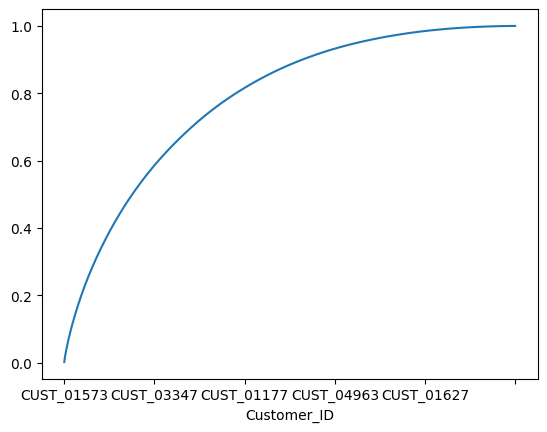

In [ ]:
#Curva acumulada de los clientes
customer_revenue_sorted = customer_revenue.sort_values(ascending=False)

cumulative_revenue = customer_revenue_sorted.cumsum() / customer_revenue_sorted.sum()

cumulative_revenue.plot()
(cumulative_revenue <= 0.8).mean()
# Eso significa que aproximadamente 38% de los clientes generan el 80% del revenue, es una concentracion moderada.
# No se depende de un grupo súper pequeño (eso reduce riesgo). Pero sí existe un grupo un poco más valioso.
# Hay espacio para empujar clientes medios hacia el segmento alto.


In [56]:
df_customer = df.groupby("Customer_ID")["Total_Amount"].sum().reset_index()

df_customer["segment"] = pd.qcut(
    df_customer["Total_Amount"],
    q=3,
    labels=["Low", "Medium", "High"]
)

### Principales hallazgos del analisis exploratorio
##### Recompra
- El 88% de los clientes realiza más de una compra.
- Aproximadamente 18% de los clientes realiza solo una compra.
- En promedio, cada cliente realiza 3.4 órdenes.
- No se observan grandes diferencias en: Delivery time; Rating; Discount
- La recompra es alta y no parece estar fuertemente explicada por estas variables simples.

Conclusión: La recompra es alta y no parece estar fuertemente explicada por variables operativas simples. El problema no parece ser retención, sino monetización y valor por cliente.


#####  Revenue
- Electronics concentra la mayor parte del revenue.
- Esto se explica principalmente por alto precio unitario, no por cantidad.
- El revenue presenta fuerte asimetría (pocas compras muy grandes explican gran parte del ingreso).
- El negocio parece depender fuertemente de productos de alto valor.
- Existe una cola larga de clientes de alto gasto. Aproximadamente 38% de los clientes generan el 80% del revenue (concentración moderada).

Conclusión:
El negocio depende por un lado de los productos premium y por clientes de alto gasto. 
No todos los clientes tienen el mismo impacto financiero.


El dataset muestra que:

La recompra no es el problema principal (ya es muy alta).
El verdadero driver de rentabilidad parece ser: 
- Ticket promedio
- Categoría comprada
- Segmento de cliente


El negocio presenta alta recompra y fuerte concentración de ingresos en categorías premium y clientes de alto valor. La oportunidad estratégica no está en aumentar la recurrencia, sino en incrementar el valor promedio por cliente y expandir el segmento de alto gasto.


Hipótesis que surgen del EDA
- Hipótesis 1: El revenue está concentrado en pocos clientes de alto gasto.

- Hipótesis 2: La recompra no depende significativamente del delivery time ni del rating.

- Hipótesis 3: Las categorías premium (Electronics, Home & Garden) impulsan el revenue más que la frecuencia de compra.

- Hipótesis 4: Existen oportunidades para incrementar rentabilidad moviendo clientes de segmento medio hacia segmento alto.

##### Problema inicial:

Identificar los factores que influyen en la recompra y el revenue para aumentar la rentabilidad.

##### Problema reformulado tras el EDA:

Identificar qué caracteriza a los clientes de alto valor y cómo aumentar el revenue promedio por cliente.
